In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw6.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 6: Clustering - PART B
### Associated lectures: [Lectures 14 and 15](https://ubc-cs.github.io/cpsc330-2025W2/#lecture-schedule-tentative)

**Due date: See [deliverable due dates](https://ubc-cs.github.io/cpsc330-2025W2/#deliverable-due-dates-tentative)**.

## Imports <a name="im"></a>

In [2]:
import os
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
pd.set_option("display.max_colwidth", 0)

<br><br><br><br>

## Exercise 3: Clustering recipe names
<hr>

In this exercise you'll cluster recipe names with some of the clustering algorithms we have seen in class. This will also involve making some attempts to pick reasonable hyperparameter values for each clustering method based on the quality of the resulting clusters. For example, for KMeans, you need to specify the number of clusters in advance, which is often challenging on real-world datasets. For DBSCAN, you need to pick appropriate `eps` and `min_samples`. For hierarchical clustering, you need to pick a suitable linkage criterion, distance metric, and prune the tree so that it's possible to visualize and interpret it. 

Here are some methods which may help you with picking reasonable values for the hyperparameters. 
- Visualize the Elbow plot (KMeans). 
- Visualize Silhouette plots. 
- Visualize resulting clusters using `plot_umap_clusters` function from Exercise 1. 
- Sample some recipes from each cluster, manually inspect whether there are coherent semantic themes. (For this, you may use the function `print_clusters` given below.) 
        
> You may use the [`yellowbrick`](https://www.scikit-yb.org/en/latest/) package for visualizing the Elbow plot and the Silhouette plots. You can intall it with

```conda install -c districtdatalabs yellowbrick```

**Note that the process of picking reasonable hyperparameter values will be exploratory, iterative, and will involve manual inspection and judgment, as there is no ground truth to verify how well the model is doing. In your solutions, please do not include everything you try. Only present the results of the most informative trials. Add a narrative to your answer so that it's easy for the grader to follow your choices and reasoning.** 

In [32]:
def print_clusters(recipes_df, cluster_labels, n_recipes=10, replace=False, random_state=None):
    """
    Given recipes_df containing recipe names and cluster assignment (labels), 
    sample and print n_recipes recipes per cluster. 

    Parameters
    -----------
    recipe_df : pandas dataframe 
        recipes dataframe containing recipe names in the "name" column
    cluster_labels : ndarray or a list
        cluster labels for each row in recipes_df 
    n_recipes : int
        number of examples to sample from each cluster
    replace: bool
        replace flag to pass to the sampling of recipe names

    Returns
    -----------
    None
    """    
    
    grouped = (
        pd.DataFrame(
            {
                "name": recipes_df["name"],
                "cluster_label": cluster_labels,
            }
        )
        .sort_values("cluster_label")
        .groupby("cluster_label")    
    )
    
    for name, group in grouped:
        print(f"Cluster {name}")        
        print(("----------").format(""))        
        print("\n".join(group.sample(n_recipes, random_state=random_state, replace=replace)['name'].tolist()))
        print("\n\n")

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.1 K-Means
rubric={points:6}

**Your tasks:**

1. Cluster recipe titles using KMeans. Make some attempts to determine the optimal number of clusters. 
2. Pick one or two best models and justify your choice.

</div>

<div class="alert alert-warning">

Solution_3.1
    
</div>

_Points:_ 6

_Type your answer here, replacing this text._

In [33]:
kmeans_10 = KMeans(n_clusters=10, random_state=42)
kmeans_10_labels = kmeans_10.fit_predict(embeddings)

In [34]:
print_clusters(recipes_df, kmeans_10_labels, n_recipes=10, random_state=42)

Cluster 0
----------
nacho joes
mallow swirl bars
oozy  palestinian  middle eastern
peachy cooler
midsummers night dream
amazing braise
spaghettini verdi
cape biryani breyani
hoosier tenderloin
mud flap



Cluster 1
----------
big chocolate chip birthday cookie
ultimate chocolate chocolate chip cookies
nelson family cookie bake ting a lings
chocolate strawberry thumbprint cookies
irresistible peanut butter cookies
backwards chocolate cookies
paleo chocolate chip coconut cookies
honey roasted peanut butter toffee swirl cookies
no butter peanut lover s peanut butter cookies
nelson cookie bake traditional spritz cookies



Cluster 2
----------
chocolate chunk coffee cake
double chocolate cherry cake
lemon frosted lemon cake
lemon zucchini cake with poppy seed
mashed potato chocolate cake
lemon coconut sheet cake
aussie carrot cake
butterscotch coffee cake
hershey s disappearing cake
ginger cake iced in lemon



Cluster 3
----------
orange and date salad  moroccan
american kitchen classic 

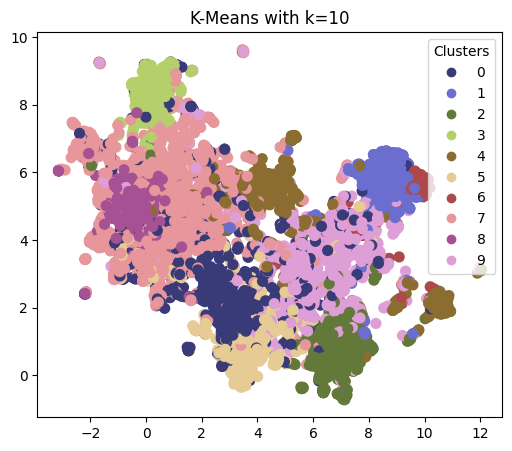

In [35]:
plot_umap_clusters(
    embeddings,
    kmeans_10_labels,
    raw_texts=recipes_df["name"].tolist(),
    title="K-Means with k=10",
    n_neighbors=10
)

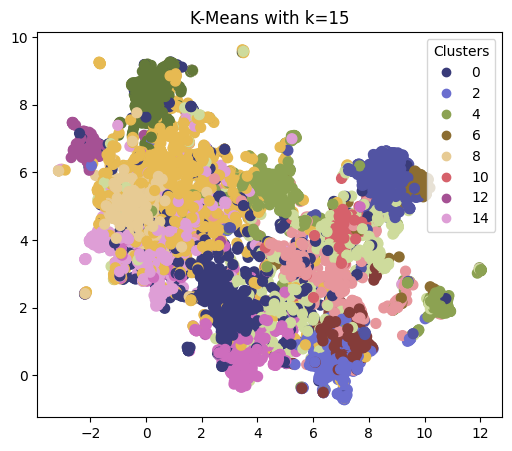

In [36]:
kmeans_15 = KMeans(n_clusters=15, random_state=42)
kmeans_15_labels = kmeans_15.fit_predict(embeddings)
plot_umap_clusters(
    embeddings,
    kmeans_15_labels,
    raw_texts=recipes_df["name"].tolist(),
    title="K-Means with k=15",
    n_neighbors=10
)

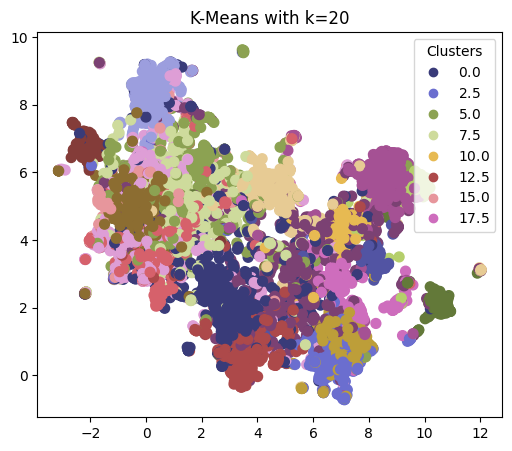

In [37]:
kmeans_20 = KMeans(n_clusters=20, random_state=42)
kmeans_20_labels = kmeans_20.fit_predict(embeddings)
plot_umap_clusters(
    embeddings,
    kmeans_20_labels,
    raw_texts=recipes_df["name"].tolist(),
    title="K-Means with k=20",
    n_neighbors=10
)

I experimented with several values of k such as 10, 15, and 20 to determine a reasonable number of clusters. With k=10, the clusters were too large and many different recipe types appeared to be grouped together. Increasing to k=20 produced more fragmented clusters that were harder to interpret since they were kind of everywhere. The clustering with k=15 provided a better balance. Therefore, I selected k=15 as the best model for clustering the recipe names.


In [38]:
...

Ellipsis

<!-- END QUESTION -->

<br><br><br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.2 DBSCAN
rubric={points:6}

**Your tasks:**

1. Cluster recipe names using `DBSCAN` with `metric="cosine"`. Make some attempts to tune the  hyperparameters `eps` and `min_samples`.

</div>

<div class="alert alert-warning">

Solution_3.2
    
</div>

_Points:_ 6

_Type your answer here, replacing this text._

In [39]:
dbscan_1 = DBSCAN(eps=0.4, min_samples=5, metric="cosine")
dbscan_1_labels = dbscan_1.fit_predict(embeddings)

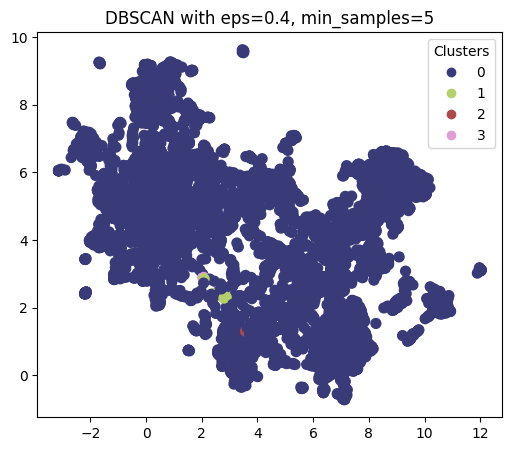

In [40]:
plot_umap_clusters(
    embeddings,
    dbscan_1_labels,
    raw_texts=recipes_df["name"].tolist(),
    title="DBSCAN with eps=0.4, min_samples=5",
    n_neighbors=10,
    ignore_noise=True
)

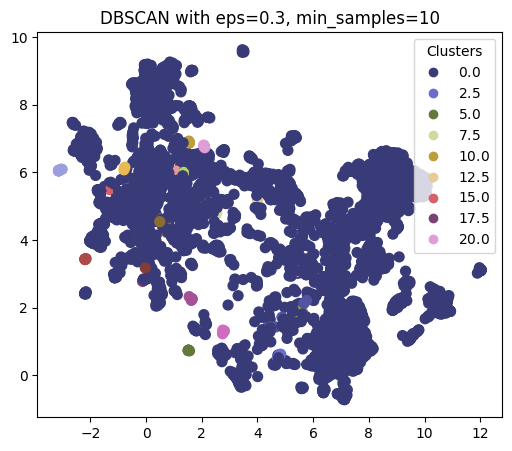

In [41]:
dbscan_1 = DBSCAN(eps=0.3, min_samples=5, metric="cosine")
dbscan_1_labels = dbscan_1.fit_predict(embeddings)
plot_umap_clusters(
    embeddings,
    dbscan_1_labels,
    raw_texts=recipes_df["name"].tolist(),
    title="DBSCAN with eps=0.3, min_samples=10",
    n_neighbors=10,
    ignore_noise=True
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.3 Hierarchical clustering
rubric={points:6}

**Your tasks:**

1. Try hierarchical clustering with `metric="cosine"` on this problem. Show a dendrogram by using a suitable truncation method. 
2. Create flat clusters by cutting the tree at the appropriate level. 

> *Note: Try orientation="left" of `dendrogram` for better readability of the dendrogram.*

</div>

<div class="alert alert-warning">

Solution_3.3
    
</div>

_Points:_ 6

_Type your answer here, replacing this text._

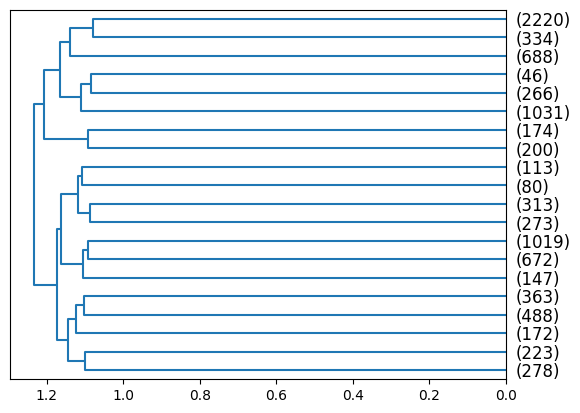

In [42]:
Z = linkage(embeddings, method="complete", metric="cosine")

plt.figure()
dendrogram(Z, truncate_mode="lastp", p=20, orientation="left")
plt.show()

In [43]:
hier_labels = fcluster(Z, t=15, criterion="maxclust")

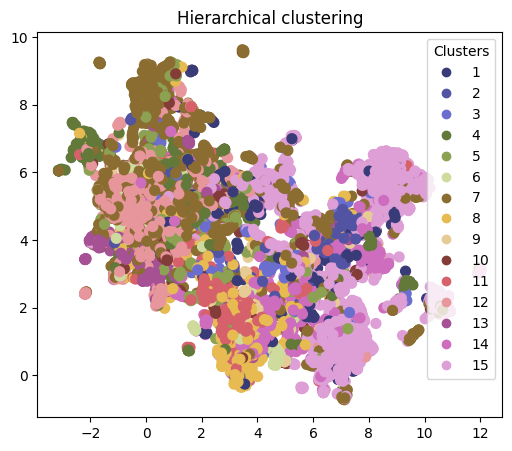

In [44]:
plot_umap_clusters(
    embeddings,
    hier_labels,
    raw_texts=recipes_df["name"].tolist(),
    title="Hierarchical clustering",
    n_neighbors=10
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.4 Manual interpretation of clusters
rubric={points:6}

**Your tasks:**

1. Label the topics/themes you see in the clusters created by different clustering methods.  
2. Do you see a common theme across clusters created by different clustering methods? Do you see any differences between the clusters created by different clustering methods?

</div>

<div class="alert alert-warning">

Solution_3.4
    
</div>

_Points:_ 6

In [45]:
print_clusters(recipes_df, kmeans_15_labels, n_recipes=10, random_state=42)

Cluster 0
----------
emily s traveling beans
betty s orange rolls
tomato bredie
blue lagoon
ambrosia macaroons
sassy middle eastern fish rub
paradise punch
schwenkbraten
peach cosmo
please don t hate us because we re rich and cheesy enchiladas



Cluster 1
----------
iola s sugar cookies
bacon chocolate chip cookies
mrs  fields cookies
carrot apple spice cookies
no butter peanut lover s peanut butter cookies
stefanie s gingerbread cookies
milk   cookie cups
simply scrumptious carrot cake cookies
nana s ranger cookies
brown sugar crackle cookies



Cluster 2
----------
gooey mandarin cake
miss ellen s pound cake
lemon lime pound cake
moist poppy seed cake
cardamom cake
four layer lemon cake
banana cinnamon bundt cake
quick   easy fudge cake
louise cake
orange swirl cake



Cluster 3
----------
lime tahini salad dressing
moroccan orange blossom scented carrot salad
bacon buttermilk dressing for spinach salad
dawn s ranch dressing
california roll   salad
kfc coleslaw dressing
cashew  crai

In [46]:
print_clusters(recipes_df, dbscan_1_labels, n_recipes=10, replace=True, random_state=42)

Cluster -1
----------
beefy calzones
chicken and cheese filo parcels
saketini
lemon lime country style pork ribs
sarasota s perfect fresh tuna  sliders
ding dong dessert
vanilla coke  alcoholic
old fashioned butter beans   ham
jamaica concentrate
garlic and asiago loaves



Cluster 0
----------
wonderful banana muffins
gov oatmeal chocolate chip cookies
lemon muffins w yogurt
applewood farmhouse hot fudge pie
yellow pudding cake with chocolate chips
marbled cinnamon sugar quick bread
becky s oatmeal bread
basic buttermilk cake
banana blackberry pie  smoothie
vienna bread  bread machine



Cluster 1
----------
butternut squash and spinach lasagna
barley butternut squash pilaf
butternut squash and chickpea tangine
butternut squash and spinach lasagna
brown rice   veggie stuffed acorn squash
butternut squash and chickpea tangine
butternut squash and chickpea tangine
butternut squash and spinach lasagna
a  butternut   acorn squash gratin
brown rice   veggie stuffed acorn squash



Cluster 

In [47]:

print_clusters(recipes_df, hier_labels, n_recipes=10, random_state=42)

Cluster 1
----------
grandma s one bowl molasses applesauce cake
maple rum cider
easy peanut sauce for spring rolls
ground beef biscuit stew
blueberry coffee cake supreme
puff pasty surprise
sweet cinnamon apple rings
blue cheese coleslaw with apples and walnuts
blueberry magic
maple leaves



Cluster 2
----------
low carb  low sugar red velvet cheesecake bars
sweet chili dipping sauce
ginger crinkles
raspberry almond bars
chocolate raspberry layer bars
glazed honey bars
buttermilk bars
mixed berry coulis
black bean pinwheels
white chocolate cranberry blondie bars



Cluster 3
----------
oven baked mostaccioli
bolo de cereveja   beer cake   portugal
individual tiramisu cups
diavolo sauce
maple pecan bread
quinoa lime biryani
spiced pecans
fritatta
macaroons
blueberry pecan pancakes



Cluster 4
----------
corned beef hash with fried eggs
chicken and potato florentine soup  olive garden
thai shrimp dumplings
ginger scented apple squash soup
spicy beef and bean soup with oven roasted pep

Although the graphs were not too clear on the groupings, after printing the labels out, the clusters can be seen significantly. 

For kmeans, the groupings were, by order of cluster number:
- Cookies, Cakes, Salads,Breads, Chocolate, Oatmeal, Savory, Chicken, Cakes, Bars, Desserts, Soups,Cocktails, Meats. 

For DBSCAN, the clusters were: 
- outliers, baking, squash, trifles, tea, dumplings, cocktails, frosting, potatoes, appetizers, bruschetta, gratin, scallopini, cordonbleu, steak, pork, stirfry, pasta, steak, lasagna, shepherdspie, potatoes.

For hierarchical:
- desserts, bars, mixed, meals, salads, tea, salads, cocktails, cocktails, appetizers, cocktails, chicken, meats, desserts, cookies


Across the different clustering methods, there are some common themes such as desserts, cocktails/drinks, meats, and savory dishes. However, the methods differ in how specifically they group recipes. K-means and hierarchical clustering produce broader categories, while DBSCAN had specific clusters focused on particular dishes or ingredients. Also, DBSCAN had outliers, which meant there were things that did not belong in any of the categories. 

<!-- END QUESTION -->

<br><br><br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Submission Instructions section at the top. 

Here is a quick checklist before submitting: 

- [ ] Restart kernel, clear outputs, and run all cells from top to bottom.  
- [ ] `.ipynb` file runs without errors and contains all outputs.  
- [ ] Only `.ipynb` and required output files are uploaded (no extra files).  
- [ ] Execution numbers start at **1** and are in order.  
- [ ] If `.ipynb` is too large and doesn't render on Gradescope, also upload a PDF/HTML version.  
- [ ] Reviewed the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions).

![](img/eva-well-done.png)